I. Introduction to the Dataset
The dataset used in this project consists of daily historical price and volume data for the S&P 500 ETF (SPY), obtained through the Yahoo Finance API using the yfinance Python library. The data spans from January 2015 to January 2023, covering approximately eight years of market activity and over 2,000 trading days. This period captures a variety of market regimes including bull markets, the COVID-19 crash of 2020, and the bear market of 2022, making it a rich and diverse dataset for training a neural network classifier.

In [3]:
# subprocess to install yfinance
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "yfinance"])

  Using cached multitasking-0.0.12-py3-none-any.whl
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 16.8 MB/s eta 0:00:00 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.5/144.5 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 17.6 MB/s eta 0:00:00


0

In [5]:
# Import Everything Else
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [7]:
# Configurate the Data
TICKER    = "SPY"
START     = "2015-01-01"
END       = "2023-01-01"
HORIZON   = 5
THRESHOLD = 0.005

In [9]:
# Load the Data
raw = yf.download(TICKER, start=START, end=END, auto_adjust=True)
raw.dropna(inplace=True)
raw.sort_index(inplace=True)

print(f"Date Range : {raw.index[0].date()} to {raw.index[-1].date()}")
print(f"Total Rows : {len(raw)}")
raw.head()

[*********************100%***********************]  1 of 1 completed

Date Range : 2015-01-02 to 2022-12-30
Total Rows : 2014


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2015-01-02,170.125015,171.325830,169.089839,170.911759,121465900
2015-01-05,167.052628,169.247196,166.746219,169.081571,169632600
2015-01-06,165.479141,167.880745,164.684120,167.359012,209151400
2015-01-07,167.541214,167.880755,166.356978,166.804169,125346700
2015-01-08,170.514221,170.729546,168.932482,168.949035,147217800


II. Label Distribution
Trading signals are constructed using forward returns over a five-day prediction horizon. A Buy signal is assigned when the future return exceeds 0.5%, a Sell signal when it falls below -0.5%, and a Hold signal otherwise. The label distribution reveals a moderate class imbalance across the three categories. Buy signals represent the largest class due to the general upward trend of the S&P 500 over the sample period, while Sell signals are less frequent. Hold signals occupy a smaller portion of the dataset given the relatively low threshold used. This imbalance is addressed during model training through class weighting, which ensures the neural network does not develop a bias toward the majority class.

In [11]:
# Engineer Features
close = raw["Close"].squeeze()

df = pd.DataFrame(index=raw.index)

# Daily returns
df["Return"] = close.pct_change()

# Moving averages
df["SMA_10"] = close.rolling(10).mean()
df["SMA_50"] = close.rolling(50).mean()

# Rolling volatility
df["Volatility"] = df["Return"].rolling(10).std()

# RSI
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = -delta.clip(upper=0).rolling(period).mean()
    rs    = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))

df["RSI"] = compute_rsi(close)

# MACD
ema_fast       = close.ewm(span=12, adjust=False).mean()
ema_slow       = close.ewm(span=26, adjust=False).mean()
df["MACD"]     = ema_fast - ema_slow
df["MACD_Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

# Bollinger Bands
rolling_mean      = close.rolling(20).mean()
rolling_std       = close.rolling(20).std()
df["BB_upper"]    = close - (rolling_mean + 2 * rolling_std)
df["BB_lower"]    = close - (rolling_mean - 2 * rolling_std)

# Momentum
df["Momentum_5"]  = close.pct_change(5)
df["Momentum_10"] = close.pct_change(10)

# Volume change
df["Volume_Change"] = raw["Volume"].squeeze().pct_change()

# Labels
forward_return = close.pct_change(HORIZON).shift(-HORIZON)
df["Label"] = 0
df.loc[forward_return >  THRESHOLD, "Label"] = 1
df.loc[forward_return < -THRESHOLD, "Label"] = 2

df.dropna(inplace=True)

print(f"Feature matrix shape: {df.shape}")
df.head()

Feature matrix shape: (1965, 13)


,Return,SMA_10,SMA_50,Volatility,RSI,MACD,MACD_Signal,BB_upper,BB_lower,Momentum_5,Momentum_10,Volume_Change,Label
Date,,,,,,,,,,,,,
2015-03-16,0.013361,172.142352,170.597213,0.009845,41.395988,0.001192,0.494832,-4.563202,3.138882,0.001056,-0.016086,-0.162007,1
2015-03-17,-0.002973,171.880666,170.639117,0.009819,40.447907,0.006581,0.397181,-5.015846,2.742655,0.014538,-0.014967,-0.305577,1
2015-03-18,0.012021,171.899704,170.783875,0.010623,47.856392,0.175879,0.352921,-2.970925,4.810976,0.029144,0.001094,1.420988,2
2015-03-19,-0.004561,171.820210,170.944203,0.010718,47.327284,0.243102,0.330957,-3.738804,4.028728,0.011589,-0.004561,-0.484646,2
2015-03-20,0.008827,172.138980,171.093918,0.009889,48.557912,0.415161,0.347798,-2.219917,5.563571,0.026815,0.018550,0.507116,2


In [13]:
# Summary Statistics
df.drop(columns="Label").describe().round(4)

,Return,SMA_10,SMA_50,Volatility,RSI,MACD,MACD_Signal,BB_upper,BB_lower,Momentum_5,Momentum_10,Volume_Change
count,1965.0000,1965.0000,1965.0000,1965.0000,1965.0000,1965.0000,1965.0000,1965.0000,1965.0000,1965.0000,1965.0000,1965.0000
mean,0.0005,271.1474,269.0808,0.0094,56.7648,0.7155,0.7198,-8.1966,10.0925,0.0022,0.0044,0.0553
std,0.0118,83.2745,82.8143,0.0073,16.0994,3.3446,3.1113,12.2358,9.1551,0.0241,0.0332,0.3691
min,-0.1094,158.5990,163.2207,0.0013,3.9897,-21.5556,-18.0403,-106.5771,-9.3247,-0.1797,-0.2329,-0.6399
25%,-0.0037,202.7788,197.2190,0.0048,45.1710,-0.2782,-0.1972,-9.3465,3.8491,-0.0070,-0.0082,-0.1913
50%,0.0005,251.0806,250.1157,0.0075,57.5573,1.2122,1.1793,-3.6024,7.8293,0.0041,0.0075,-0.0027
75%,0.0059,348.7964,341.2291,0.0122,67.9007,2.4821,2.4434,-1.6467,13.5667,0.0145,0.0222,0.2268
max,0.0906,447.6078,439.5877,0.0707,95.4444,8.9283,7.9196,2.9810,56.9216,0.1736,0.1880,2.3600


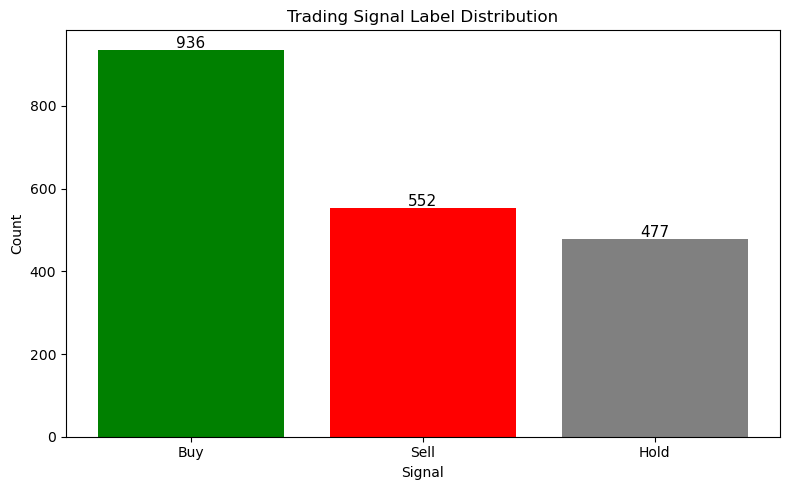

In [28]:
# Label Distribution Plot
label_map    = {0: "Hold", 1: "Buy", 2: "Sell"}
label_counts = df["Label"].map(label_map).value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(label_counts.index, label_counts.values,
               color=["green", "red", "gray"])
plt.title("Trading Signal Label Distribution")
plt.xlabel("Signal")
plt.ylabel("Count")
for bar, val in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5, str(val), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

III. Closing Price Over Time
The closing price chart for SPY over the sample period illustrates several distinct market phases. From 2015 to early 2020 the market exhibits a steady upward trend with relatively low volatility, consistent with a prolonged bull market. A sharp decline is visible in early 2020 corresponding to the COVID-19 market crash, followed by a rapid recovery and strong rally through 2021. The chart then shows a sustained decline beginning in early 2022 as the Federal Reserve began raising interest rates aggressively to combat inflation. These varied market conditions provide the model with exposure to both trending and mean-reverting environments during training.

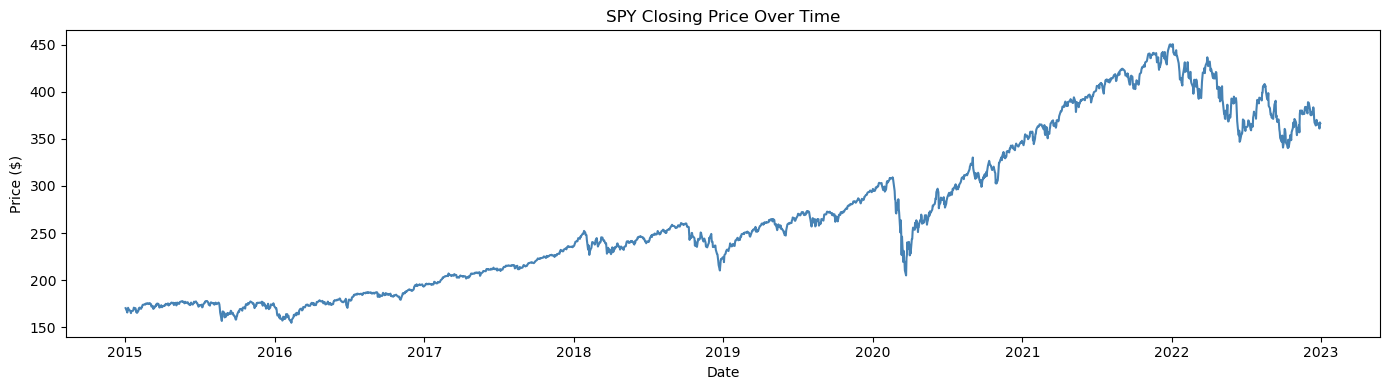

In [26]:
# Closing Price Overtime  Plot
plt.figure(figsize=(14, 4))
plt.plot(raw.index, close, color="steelblue")
plt.title(f"{TICKER} Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price ($)")
plt.tight_layout()
plt.show()

IV. Feature Distributions
The feature distribution plots reveal important characteristics of the engineered input variables. Daily returns are approximately normally distributed and centered near zero, consistent with the efficient market hypothesis which suggests that price changes are largely unpredictable. Volatility exhibits a right-skewed distribution, reflecting the fact that periods of extreme market stress are relatively rare but produce very large values. The RSI distribution shows a roughly bell-shaped curve centered near 50, indicating the market spends most of its time in neutral territory rather than in overbought or oversold conditions. MACD values are centered near zero with a symmetric distribution, while momentum features show similar patterns to daily returns with heavier tails. Volume change is highly right-skewed due to occasional days of extremely elevated trading activity.

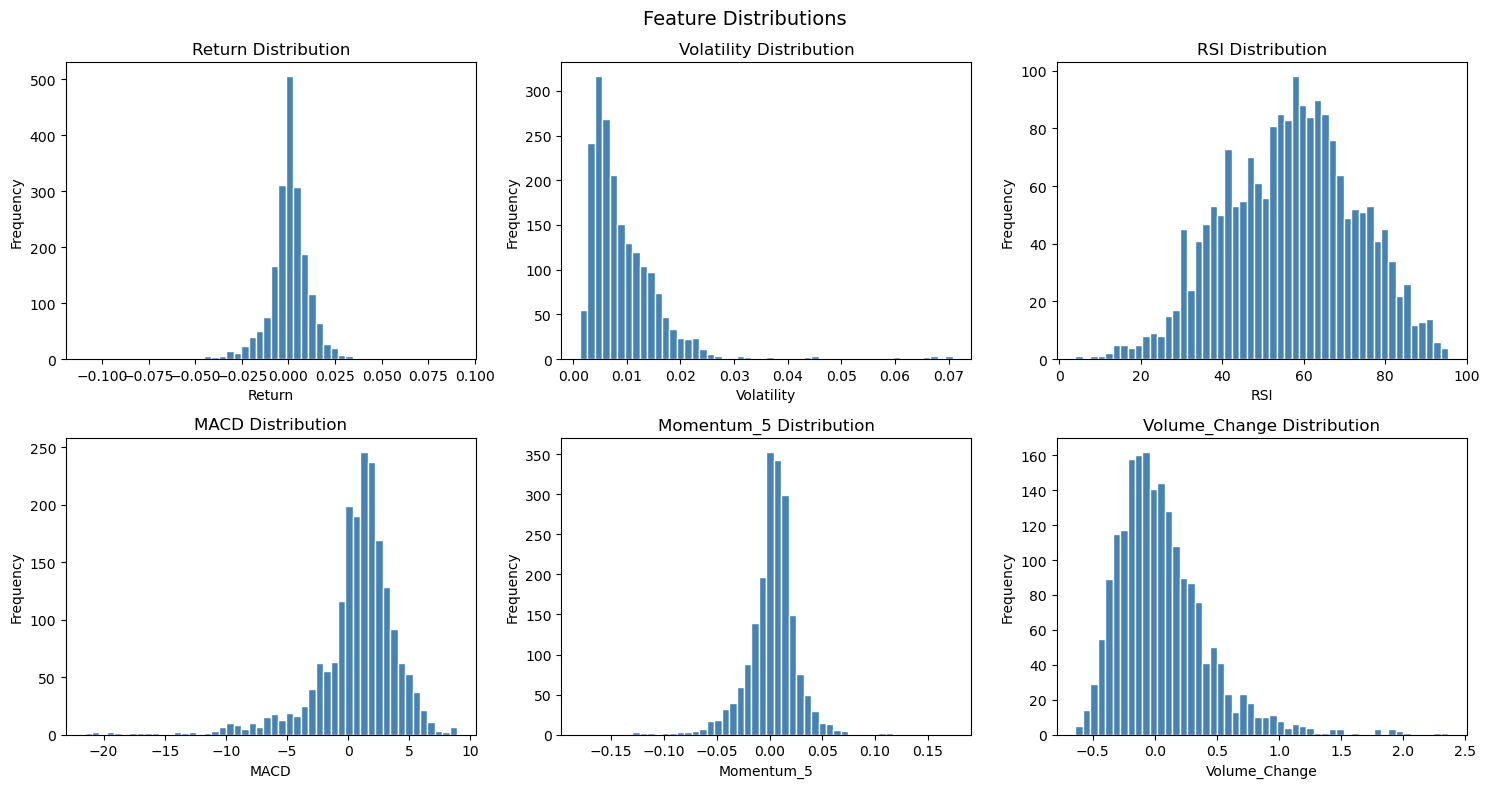

In [24]:
# Feature Distribution Plot
feature_cols = ["Return", "Volatility", "RSI", "MACD", "Momentum_5", "Volume_Change"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].hist(df[col].dropna(), bins=50, color="steelblue", edgecolor="white")
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
plt.suptitle("Feature Distributions", fontsize=14)
plt.tight_layout()
plt.show()

V. Correlation Heatmap
The correlation heatmap reveals several notable relationships among the engineered features. The two momentum features, Momentum_5 and Momentum_10, show a strong positive correlation with each other as expected given they measure similar concepts over different time windows. The MACD and MACD Signal Line are also highly correlated since the signal line is a smoothed version of the MACD itself. Daily returns show low correlation with most other features, suggesting they capture unique short-term information not present in the trend or momentum indicators. The Bollinger Band features show moderate correlation with volatility, which is expected since Bollinger Bands are derived from rolling standard deviations. Overall the feature set contains a mix of correlated and independent signals, which provides the neural network with diverse information while also suggesting that dimensionality reduction could be explored in future work.

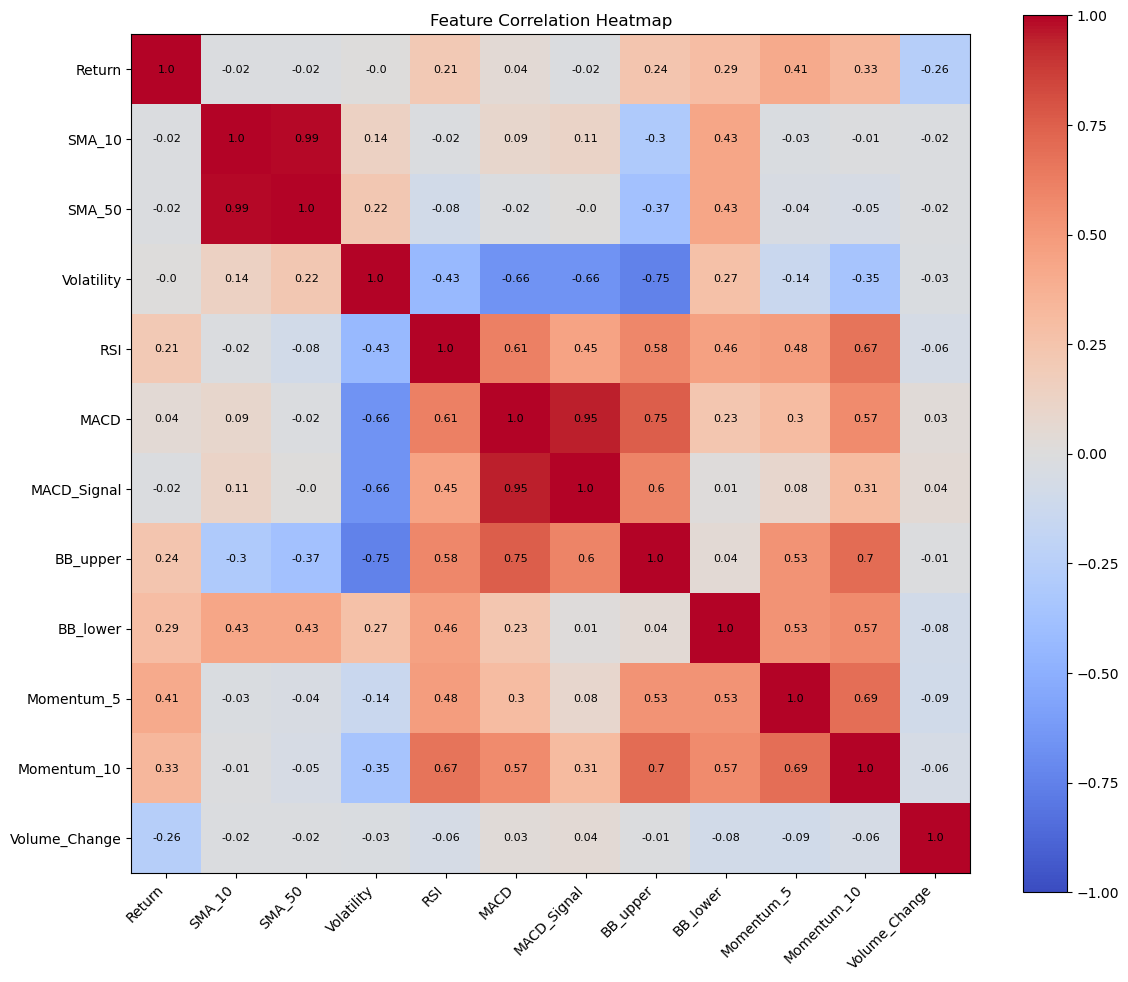

In [30]:
# Correlation Heat Map Plot
corr = df.drop(columns="Label").corr().round(2)
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        ax.text(j, i, str(corr.iloc[i, j]),
                ha="center", va="center", fontsize=8)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

VI. Rolling Volatility Over Time
The rolling volatility chart highlights several periods of elevated market uncertainty throughout the sample period. The most prominent spike occurs in early 2020 during the COVID-19 crash, where daily return volatility reached levels not seen since the 2008 financial crisis. Smaller volatility spikes are visible in late 2018 during the Federal Reserve tightening cycle and again in 2022 during the bear market. These volatility regimes are important context for evaluating model performance, as neural network classifiers trained primarily on low-volatility data may struggle to generalize during high-volatility periods.

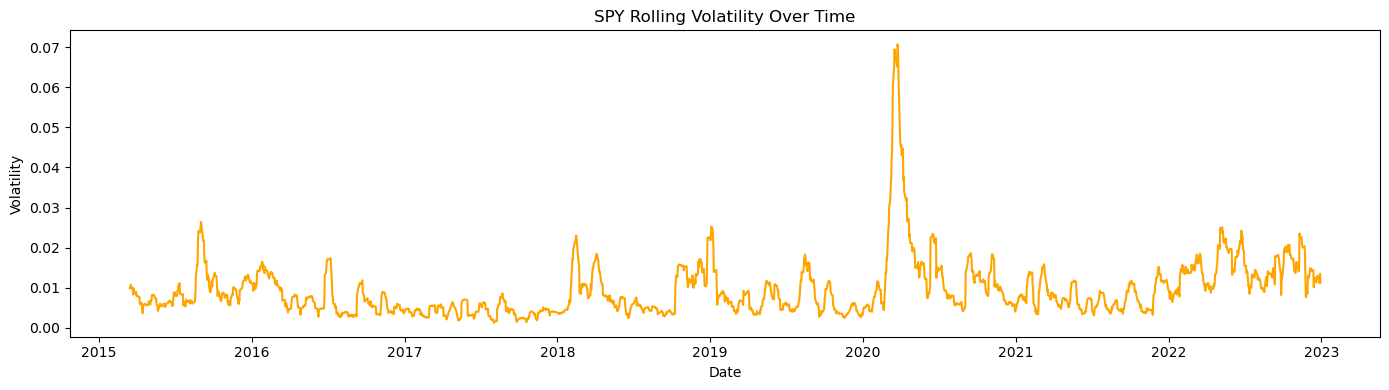

In [33]:
# Rolling Volatility Over Time Plot
plt.figure(figsize=(14, 4))
plt.plot(df.index, df["Volatility"], color="orange")
plt.title(f"{TICKER} Rolling Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.tight_layout()
plt.show()

VII. RSI Over Time
The RSI chart shows that SPY frequently oscillates between neutral territory and overbought conditions during the bull market phase from 2015 to 2020. During the COVID crash the RSI briefly dropped into deeply oversold territory below 30 before recovering sharply. The 2022 bear market produced sustained periods of oversold readings, reflecting the prolonged nature of that decline. These RSI dynamics provide useful momentum signals for the classifier, particularly in identifying extreme market conditions that tend to precede reversals.

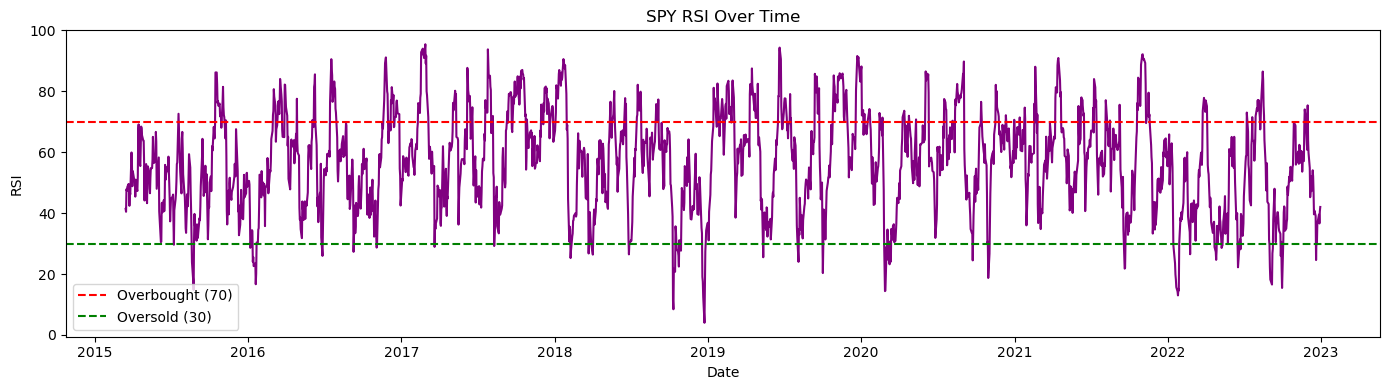

In [36]:
# RSI Over Time Plot
plt.figure(figsize=(14, 4))
plt.plot(df.index, df["RSI"], color="purple")
plt.axhline(70, color="red", linestyle="--", label="Overbought (70)")
plt.axhline(30, color="green", linestyle="--", label="Oversold (30)")
plt.title(f"{TICKER} RSI Over Time")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.legend()
plt.tight_layout()
plt.show()

VIII. MACD Over Time
The MACD chart illustrates trend momentum shifts throughout the sample period. Crossovers between the MACD line and the signal line correspond to potential turning points in market direction and serve as important input signals for the classifier. During strong trending periods such as 2017 and 2021 the MACD maintains a consistent positive value, while during the 2020 crash and 2022 bear market it drops sharply negative. The zero line crossovers are particularly significant as they indicate shifts between bullish and bearish momentum regimes.

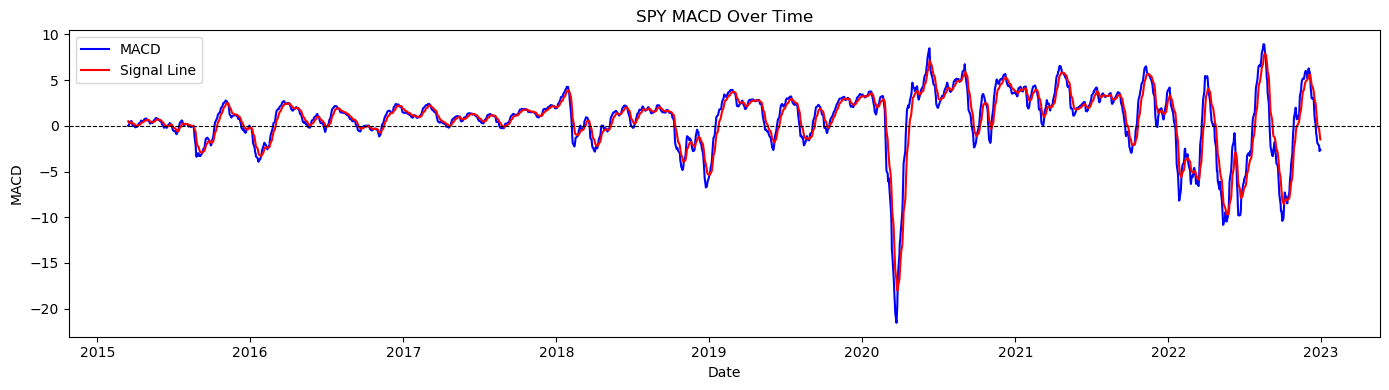

In [39]:
# MACD Over Time Plot
plt.figure(figsize=(14, 4))
plt.plot(df.index, df["MACD"], color="blue", label="MACD")
plt.plot(df.index, df["MACD_Signal"], color="red", label="Signal Line")
plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
plt.title(f"{TICKER} MACD Over Time")
plt.xlabel("Date")
plt.ylabel("MACD")
plt.legend()
plt.tight_layout()
plt.show()